# 5. Final Models — Multi-Channel, Binary, and Ensemble

This notebook applies three strategies to improve classification:

1. **Multi-channel spectrograms**: Stack mel + delta + delta-delta as 3 input channels, giving the model explicit temporal change information (similar to RGB for images)
2. **Binary classification**: Normal vs Abnormal — the clinically actionable question
3. **Ensemble**: Combine best ML and DL predictions for robust final output

We also add demographic features as a **separate branch** to the CRNN, allowing the model to learn from both audio and patient metadata while keeping these contributions transparent and auditable.

### A note on reported accuracies
Published results on the ICBHI dataset range from 50% to 99%+. This enormous variation stems primarily from evaluation methodology — specifically whether the train/test split is **patient-aware**. We use strict patient-aware splitting throughout, meaning no patient appears in more than one split. This produces lower but honest results that reflect real-world deployment, where the model must diagnose patients it has never encountered before.

In [1]:
import sys
sys.path.append(r"E:\GitHub\lung-sound-classification")

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import librosa
from tqdm import tqdm
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report

from src.config import *
from src.data_loader import patient_split, load_diagnosis, load_demographics
from src.evaluate import (
    evaluate_predictions, plot_confusion_matrix,
    plot_training_curves, compare_models, get_device
)

device = get_device()
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


## 5.1 Data Preparation
Loading cycle dataset and merging with demographic information. Demographics (age, sex, BMI) will be used as auxiliary features in a multi-modal model, while keeping the audio pathway as the primary signal.

In [2]:
cycle_df = pd.read_csv(DATA_DIR / 'cycle_dataset.csv')
cycle_df['label'] = cycle_df['label'].astype(int)

# Load and merge demographics
demographics_df = load_demographics()
cycle_df = cycle_df.merge(demographics_df, on='patient_id', how='left')

# Create binary label: 0=Normal, 1=Abnormal
cycle_df['label_binary'] = (cycle_df['label'] > 0).astype(int)

# Encode sex
cycle_df['sex_encoded'] = (cycle_df['sex'] == 'M').astype(float)

# Fill missing demographics with median
for col in ['age', 'adult_bmi', 'child_weight', 'child_height']:
    cycle_df[col] = pd.to_numeric(cycle_df[col], errors='coerce')
    cycle_df[col] = cycle_df[col].fillna(cycle_df[col].median())

print(f"Total cycles: {len(cycle_df)}")
print(f"\n4-class distribution:\n{cycle_df['label'].value_counts().sort_index()}")
print(f"\nBinary distribution:\n{cycle_df['label_binary'].value_counts()}")

# Patient-aware split
train_df, val_df, test_df = patient_split(cycle_df)

Total cycles: 6898

4-class distribution:
label
0    3642
1    1864
2     886
3     506
Name: count, dtype: int64

Binary distribution:
label_binary
0    3642
1    3256
Name: count, dtype: int64
Split sizes — Train: 3809, Val: 1386, Test: 1703
Unique patients — Train: 81, Val: 19, Test: 26


## 5.2 Multi-Channel Spectrogram Dataset
Instead of a single mel spectrogram channel, we create a **3-channel input**:

| Channel | Content | What it captures |
|---------|---------|-----------------|
| 1 | Log-mel spectrogram | Frequency energy distribution |
| 2 | Delta (1st derivative) | Rate of spectral change — onset/offset of sounds |
| 3 | Delta-delta (2nd derivative) | Acceleration of spectral change — transient events |

Crackles produce sharp spikes in delta channels (sudden onset), while wheezes show sustained energy in the mel channel with minimal delta variation. This distinction is explicit in multi-channel input but implicit (and harder to learn) in single-channel.

In [3]:
CYCLE_DUR = 4.0
TARGET_LEN = int(CYCLE_DUR * SAMPLE_RATE)


def augment_audio(y, sr=SAMPLE_RATE):
    """Audio-level augmentation."""
    if np.random.random() > 0.5:
        y = y + np.random.normal(0, np.random.uniform(0.001, 0.015), len(y))
    if np.random.random() > 0.5:
        shift = int(np.random.uniform(-0.2, 0.2) * sr)
        y = np.roll(y, shift)
        if shift > 0: y[:shift] = 0
        elif shift < 0: y[shift:] = 0
    if np.random.random() > 0.5:
        y = y * np.random.uniform(0.7, 1.3)
    return y.astype(np.float32)


def make_multichannel_spectrogram(y, sr=SAMPLE_RATE):
    """Create 3-channel spectrogram: mel + delta + delta-delta."""
    mel_spec = librosa.feature.melspectrogram(
        y=y, sr=sr, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH
    )
    log_mel = librosa.power_to_db(mel_spec, ref=np.max)

    # Compute deltas
    delta = librosa.feature.delta(log_mel, order=1)
    delta2 = librosa.feature.delta(log_mel, order=2)

    # Normalise each channel independently
    channels = []
    for ch in [log_mel, delta, delta2]:
        mean, std = ch.mean(), ch.std()
        if std > 0:
            ch = (ch - mean) / std
        else:
            ch = ch - mean
        channels.append(ch)

    # Stack: (3, n_mels, time)
    return np.stack(channels, axis=0)


class MultiChannelDataset(Dataset):
    """Dataset with 3-channel spectrograms and optional demographic features."""

    def __init__(self, df, augment=False, include_demographics=False):
        self.df = df.reset_index(drop=True)
        self.augment = augment
        self.include_demographics = include_demographics

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Load audio
        try:
            y, _ = librosa.load(row['audio_path'], sr=SAMPLE_RATE,
                                offset=row['start'], duration=row['end'] - row['start'])
        except:
            y = np.zeros(TARGET_LEN, dtype=np.float32)

        # Pad/truncate
        if len(y) < TARGET_LEN:
            y = np.pad(y, (0, TARGET_LEN - len(y)))
        else:
            y = y[:TARGET_LEN]

        if self.augment:
            y = augment_audio(y)

        # Multi-channel spectrogram
        spec = make_multichannel_spectrogram(y)
        spec_tensor = torch.FloatTensor(spec)

        label_4class = torch.LongTensor([row['label']])[0]
        label_binary = torch.LongTensor([row['label_binary']])[0]

        if self.include_demographics:
            demo = torch.FloatTensor([
                row['age'] / 100.0,          # normalise age
                row['sex_encoded'],
                row['adult_bmi'] / 50.0,      # normalise BMI
            ])
            return spec_tensor, demo, label_4class, label_binary

        return spec_tensor, label_4class, label_binary


# Test
test_ds = MultiChannelDataset(train_df.head(4), augment=True, include_demographics=True)
spec, demo, label4, label2 = test_ds[0]
print(f"Spectrogram shape: {spec.shape}")  # (3, 128, time)
print(f"Demographics: {demo}")
print(f"4-class label: {label4}, Binary label: {label2}")
print(f"Channel means: {[f'{spec[i].mean():.3f}' for i in range(3)]}")
print(f"Channel stds:  {[f'{spec[i].std():.3f}' for i in range(3)]}")

Spectrogram shape: torch.Size([3, 128, 173])
Demographics: tensor([0.7000, 0.0000, 0.6600])
4-class label: 2, Binary label: 1
Channel means: ['0.000', '-0.000', '-0.000']
Channel stds:  ['1.000', '1.000', '1.000']


## 5.3 Visualise Multi-Channel Input
Showing how the 3 channels capture different aspects of each sound class. Note how crackles show sharp spikes in delta channels while wheezes show sustained horizontal bands in the mel channel.

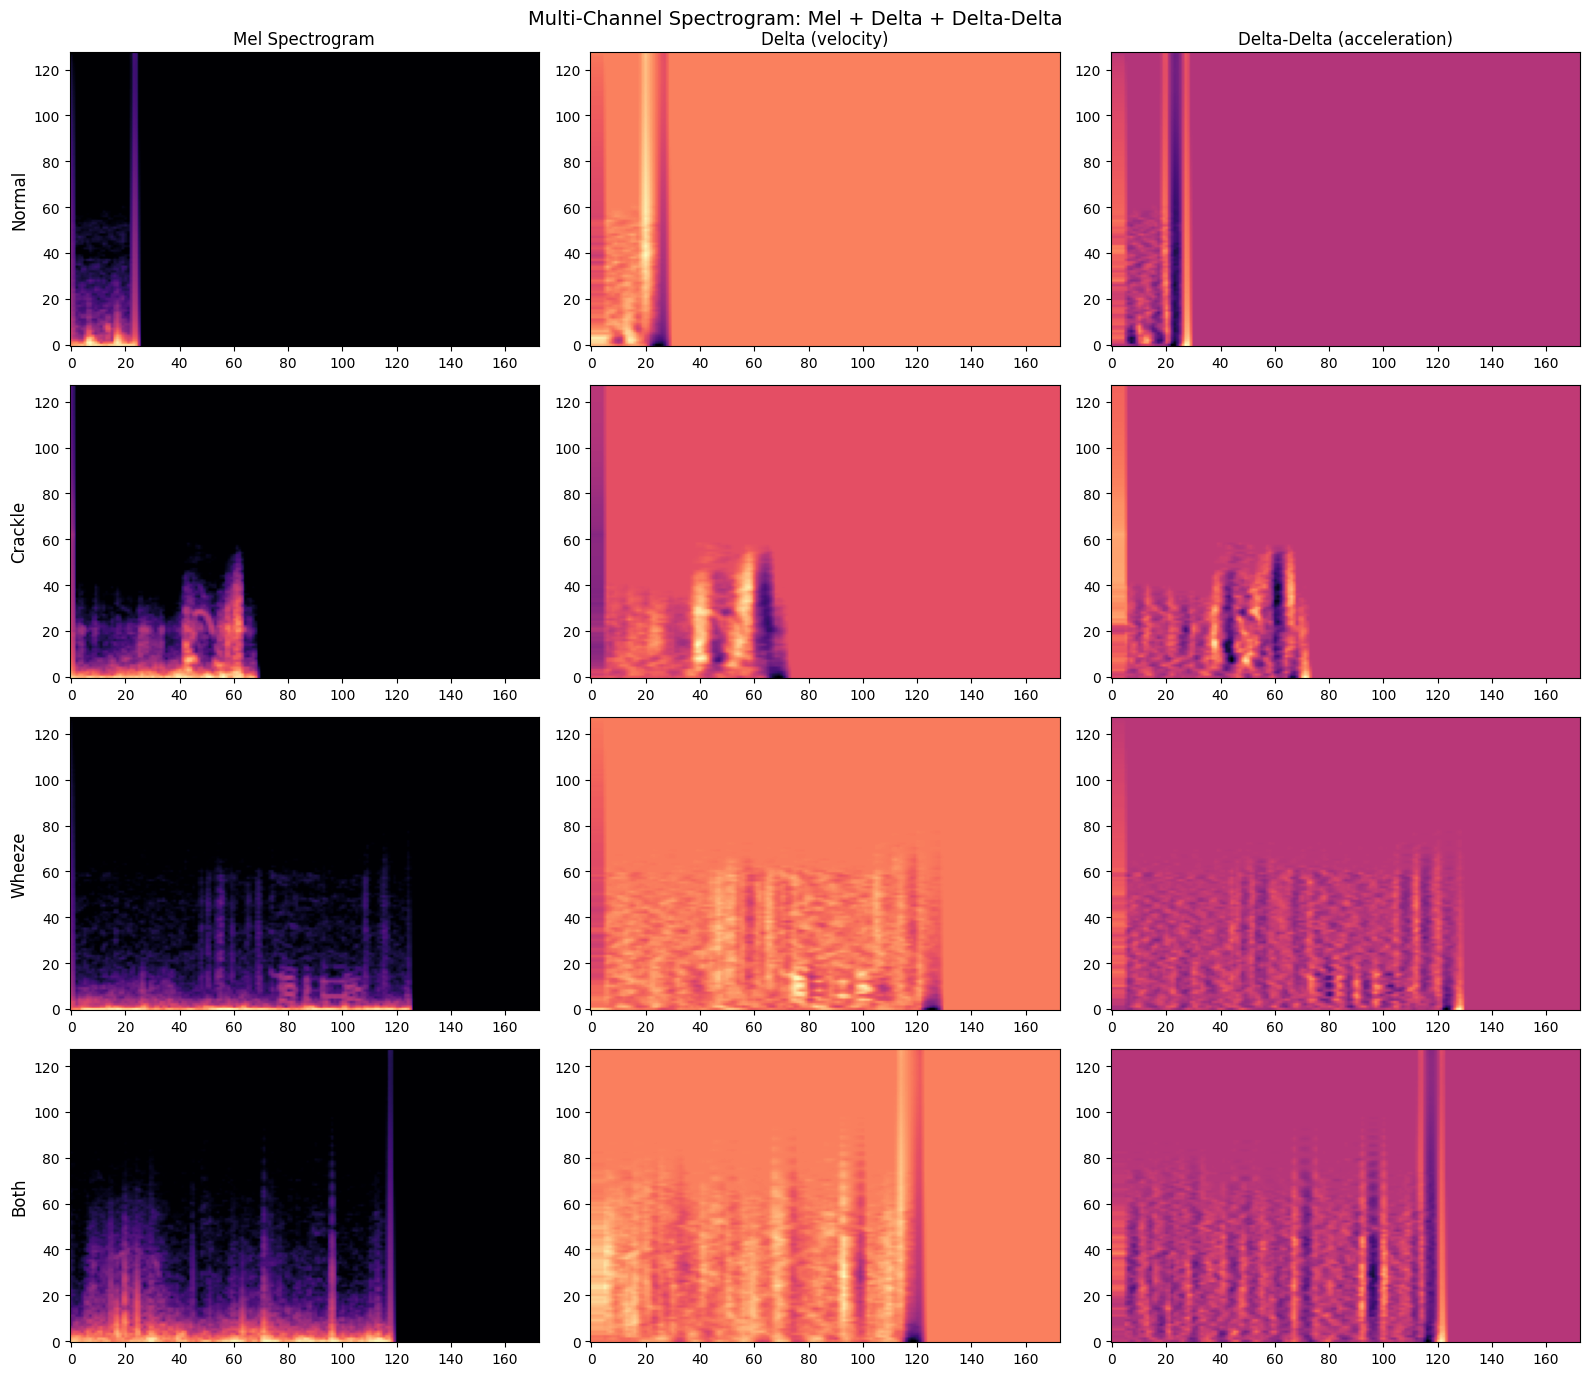

In [4]:
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
channel_names = ['Mel Spectrogram', 'Delta (velocity)', 'Delta-Delta (acceleration)']

for i, label in enumerate(range(4)):
    sample = cycle_df[cycle_df['label'] == label].iloc[0]
    y, _ = librosa.load(sample['audio_path'], sr=SAMPLE_RATE,
                        offset=sample['start'], duration=sample['end'] - sample['start'])
    if len(y) < TARGET_LEN:
        y = np.pad(y, (0, TARGET_LEN - len(y)))
    else:
        y = y[:TARGET_LEN]

    spec = make_multichannel_spectrogram(y)

    for j in range(3):
        axes[i, j].imshow(spec[j], aspect='auto', origin='lower', cmap='magma')
        if i == 0:
            axes[i, j].set_title(channel_names[j], fontsize=12)
        if j == 0:
            axes[i, j].set_ylabel(CYCLE_CLASS_NAMES[label], fontsize=12)

plt.suptitle('Multi-Channel Spectrogram: Mel + Delta + Delta-Delta', fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'multichannel_spectrograms.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# Create data loaders
train_dataset = MultiChannelDataset(train_df, augment=True, include_demographics=True)
val_dataset = MultiChannelDataset(val_df, augment=False, include_demographics=True)
test_dataset = MultiChannelDataset(test_df, augment=False, include_demographics=True)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

# Class weights for 4-class
y_train_4 = train_df['label'].values
weights_4class = compute_class_weight('balanced', classes=np.unique(y_train_4), y=y_train_4)
weights_4class = torch.FloatTensor(weights_4class)
print(f"4-class weights: {dict(zip(CYCLE_CLASS_NAMES, weights_4class.numpy()))}")

# Class weights for binary
y_train_bin = train_df['label_binary'].values
weights_binary = compute_class_weight('balanced', classes=np.unique(y_train_bin), y=y_train_bin)
weights_binary = torch.FloatTensor(weights_binary)
print(f"Binary weights: Normal={weights_binary[0]:.3f}, Abnormal={weights_binary[1]:.3f}")

4-class weights: {'Normal': np.float32(0.4219096), 'Crackle': np.float32(1.132283), 'Wheeze': np.float32(1.9394094), 'Both': np.float32(4.328409)}
Binary weights: Normal=0.844, Abnormal=1.227


## 5.4 Multi-Modal CRNN (Audio + Demographics)
Architecture with two branches:
- **Audio branch**: CNN extracts spatial features from 3-channel spectrogram → BiGRU models temporal evolution → Attention pooling
- **Demographics branch**: Small MLP processes age, sex, BMI
- **Fusion**: Concatenate audio and demographic embeddings → Final classifier

The demographic branch is deliberately kept small (3 features → 16-dim embedding) so the model cannot rely on demographics alone. The audio pathway remains the primary signal.

In [6]:
class MultiModalCRNN(nn.Module):
    """
    Multi-channel CRNN with demographic fusion.
    Audio: 3-channel spectrogram → CNN → BiGRU → Attention
    Demographics: MLP → 16-dim embedding
    Fusion: Concatenate → Classifier
    """

    def __init__(self, num_classes=4, hidden_size=128, num_layers=2, n_demo=3):
        super().__init__()

        # Audio CNN (3 input channels for mel + delta + delta-delta)
        self.cnn = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d((2, 1)), nn.Dropout2d(0.1),

            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d((2, 1)), nn.Dropout2d(0.1),

            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d((2, 1)), nn.Dropout2d(0.15),

            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d((2, 1)), nn.Dropout2d(0.2),
        )

        cnn_freq_out = N_MELS // 16  # 8
        rnn_input = 256 * cnn_freq_out

        self.rnn = nn.GRU(
            input_size=rnn_input, hidden_size=hidden_size,
            num_layers=num_layers, batch_first=True,
            bidirectional=True, dropout=0.3 if num_layers > 1 else 0,
        )

        self.attention = nn.Sequential(
            nn.Linear(hidden_size * 2, 64), nn.Tanh(), nn.Linear(64, 1),
        )

        # Demographics branch (deliberately small)
        self.demo_branch = nn.Sequential(
            nn.Linear(n_demo, 16),
            nn.ReLU(),
            nn.Dropout(0.2),
        )

        # Fusion classifier
        fusion_size = hidden_size * 2 + 16  # audio + demographics
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(fusion_size, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes),
        )

    def forward(self, spec, demo):
        batch_size = spec.size(0)

        # Audio pathway
        cnn_out = self.cnn(spec)
        _, c, f, t = cnn_out.shape
        cnn_out = cnn_out.permute(0, 3, 1, 2).reshape(batch_size, t, c * f)

        rnn_out, _ = self.rnn(cnn_out)
        attn = torch.softmax(self.attention(rnn_out), dim=1)
        audio_embed = torch.sum(rnn_out * attn, dim=1)

        # Demographics pathway
        demo_embed = self.demo_branch(demo)

        # Fusion
        fused = torch.cat([audio_embed, demo_embed], dim=1)
        return self.classifier(fused)


# Also define audio-only version (same architecture, no demographics)
class AudioOnlyCRNN(nn.Module):
    """CRNN with 3-channel input but no demographic features."""

    def __init__(self, num_classes=4, hidden_size=128, num_layers=2):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d((2, 1)), nn.Dropout2d(0.1),

            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d((2, 1)), nn.Dropout2d(0.1),

            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d((2, 1)), nn.Dropout2d(0.15),

            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d((2, 1)), nn.Dropout2d(0.2),
        )

        cnn_freq_out = N_MELS // 16
        rnn_input = 256 * cnn_freq_out

        self.rnn = nn.GRU(
            input_size=rnn_input, hidden_size=hidden_size,
            num_layers=num_layers, batch_first=True,
            bidirectional=True, dropout=0.3 if num_layers > 1 else 0,
        )

        self.attention = nn.Sequential(
            nn.Linear(hidden_size * 2, 64), nn.Tanh(), nn.Linear(64, 1),
        )

        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(hidden_size * 2, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes),
        )

    def forward(self, spec):
        batch_size = spec.size(0)
        cnn_out = self.cnn(spec)
        _, c, f, t = cnn_out.shape
        cnn_out = cnn_out.permute(0, 3, 1, 2).reshape(batch_size, t, c * f)
        rnn_out, _ = self.rnn(cnn_out)
        attn = torch.softmax(self.attention(rnn_out), dim=1)
        context = torch.sum(rnn_out * attn, dim=1)
        return self.classifier(context)


model_audio = AudioOnlyCRNN(num_classes=4).to(device)
model_multi = MultiModalCRNN(num_classes=4).to(device)
print(f"Audio-only CRNN: {sum(p.numel() for p in model_audio.parameters()):,} params")
print(f"Multi-modal CRNN: {sum(p.numel() for p in model_multi.parameters()):,} params")

Audio-only CRNN: 2,585,957 params
Multi-modal CRNN: 2,587,045 params


## 5.5 Training Functions
Modified training loop to handle both audio-only and multi-modal models.

In [10]:
def train_model(model, train_loader, val_loader, num_epochs=60,
                lr=3e-4, class_weights=None, model_name="model",
                patience=15, multimodal=False):
    """Training loop supporting both audio-only and multi-modal models."""
    model = model.to(device)

    if class_weights is not None:
        class_weights = class_weights.to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    optimiser = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-3)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=num_epochs, eta_min=1e-6)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_loss = float('inf')
    best_val_acc = 0.0
    patience_counter = 0

    for epoch in range(num_epochs):
        # Train
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for batch in train_loader:
            if multimodal:
                specs, demos, labels_4, labels_bin = batch
                specs, demos = specs.to(device), demos.to(device)
                labels = labels_4.to(device)
                optimiser.zero_grad()
                outputs = model(specs, demos)
            else:
                specs, demos, labels_4, labels_bin = batch
                specs = specs.to(device)
                labels = labels_4.to(device)
                optimiser.zero_grad()
                outputs = model(specs)

            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimiser.step()

            running_loss += loss.item() * specs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_loss = running_loss / total
        train_acc = correct / total

        # Validate
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for batch in val_loader:
                if multimodal:
                    specs, demos, labels_4, labels_bin = batch
                    specs, demos = specs.to(device), demos.to(device)
                    labels = labels_4.to(device)
                    outputs = model(specs, demos)
                else:
                    specs, demos, labels_4, labels_bin = batch
                    specs = specs.to(device)
                    labels = labels_4.to(device)
                    outputs = model(specs)

                loss = criterion(outputs, labels)
                val_loss += loss.item() * specs.size(0)
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        val_loss /= val_total
        val_acc = val_correct / val_total
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_val_acc = val_acc
            torch.save(model.state_dict(), MODELS_DIR / f"{model_name}_best.pt")
            patience_counter = 0
        else:
            patience_counter += 1

        if (epoch + 1) % 5 == 0 or patience_counter == 0:
            print(f"Epoch [{epoch+1:3d}/{num_epochs}] "
                  f"Train: {train_loss:.4f}/{train_acc:.4f}  "
                  f"Val: {val_loss:.4f}/{val_acc:.4f}  "
                  f"{'star' if patience_counter == 0 else ''}")

        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

    print(f"\nBest val loss: {best_val_loss:.4f}, Best val acc: {best_val_acc:.4f}")
    return history


def evaluate_model(model, test_loader, model_name, multimodal=False):
    """Evaluate and return predictions."""
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for batch in test_loader:
            if multimodal:
                specs, demos, labels_4, labels_bin = batch
                specs, demos = specs.to(device), demos.to(device)
                outputs = model(specs, demos)
            else:
                specs, demos, labels_4, labels_bin = batch
                specs = specs.to(device)
                outputs = model(specs)
            _, predicted = outputs.max(1)
            y_true.extend(labels_4.numpy())
            y_pred.extend(predicted.cpu().numpy())

    y_true, y_pred = np.array(y_true), np.array(y_pred)
    results = evaluate_predictions(y_true, y_pred, title=model_name)
    plot_confusion_matrix(y_true, y_pred, title=model_name,
                          save_path=FIGURES_DIR / f"cm_{model_name.lower().replace(' ', '_')}.png")
    return results, y_true, y_pred

## 5.6 Train Audio-Only Multi-Channel CRNN
3-channel spectrogram input (mel + delta + delta-delta), no demographic features. This isolates the improvement from multi-channel input alone.

  Training Audio-Only 3-Channel CRNN
Epoch [  1/60] Train: 1.3817/0.3261  Val: 1.3949/0.2792  star
Epoch [  2/60] Train: 1.3515/0.3339  Val: 1.3942/0.1061  star
Epoch [  5/60] Train: 1.2951/0.3896  Val: 1.4607/0.1400  
Epoch [  6/60] Train: 1.2632/0.3775  Val: 1.3026/0.4603  star
Epoch [  8/60] Train: 1.1321/0.4439  Val: 1.2742/0.4697  star
Epoch [ 10/60] Train: 1.0645/0.4894  Val: 1.2208/0.4711  star
Epoch [ 15/60] Train: 1.0349/0.5012  Val: 1.2231/0.4834  
Epoch [ 20/60] Train: 0.9259/0.5621  Val: 1.3064/0.4704  
Epoch [ 25/60] Train: 0.8607/0.6030  Val: 1.4362/0.4430  

Early stopping at epoch 25

Best val loss: 1.2208, Best val acc: 0.4711
  Saved: E:\GitHub\lung-sound-classification\outputs\figures\audio_crnn_3ch_curves.png


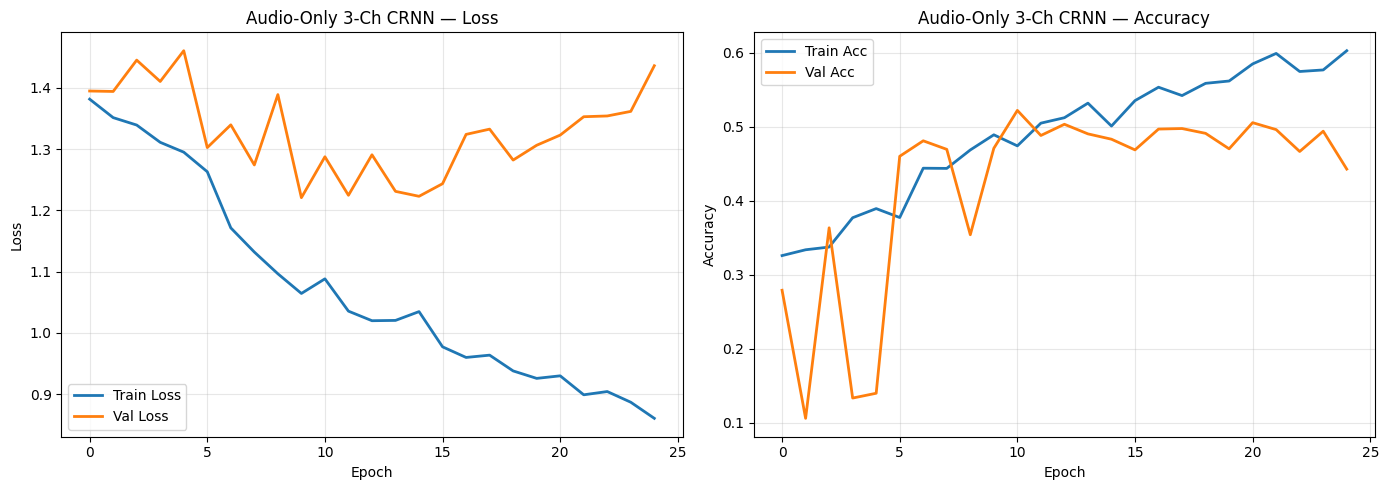


  Audio-Only 3-Ch CRNN
  Accuracy:          0.3412
  F1 (macro):        0.3349
  F1 (weighted):     0.3382

              precision    recall  f1-score   support

      Normal       0.63      0.20      0.31       800
     Crackle       0.38      0.44      0.40       517
      Wheeze       0.22      0.47      0.30       224
        Both       0.23      0.54      0.32       162

    accuracy                           0.34      1703
   macro avg       0.37      0.41      0.33      1703
weighted avg       0.46      0.34      0.34      1703

  Saved: E:\GitHub\lung-sound-classification\outputs\figures\cm_audio-only_3-ch_crnn.png


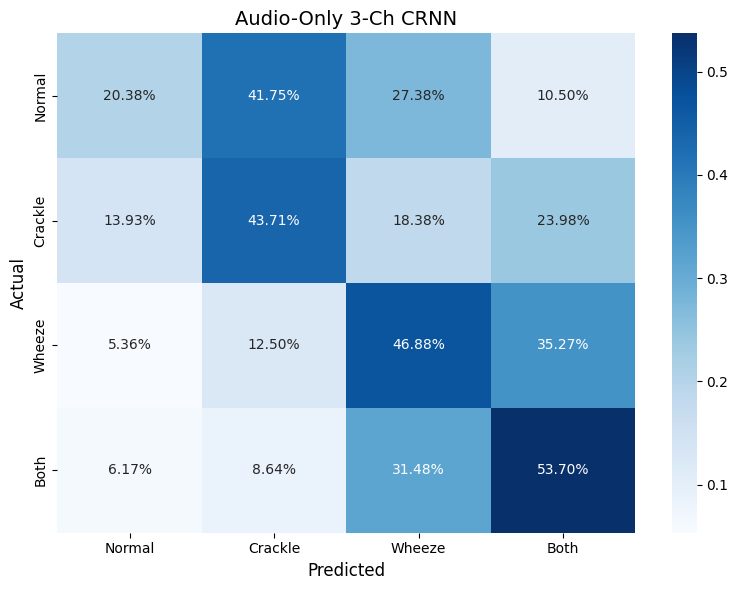

In [11]:
print("=" * 60)
print("  Training Audio-Only 3-Channel CRNN")
print("=" * 60)

audio_history = train_model(
    model_audio, train_loader, val_loader,
    num_epochs=60, lr=3e-4, class_weights=weights_4class,
    model_name="audio_crnn_3ch", patience=15, multimodal=False
)

model_audio.load_state_dict(torch.load(MODELS_DIR / "audio_crnn_3ch_best.pt", map_location=device))
plot_training_curves(audio_history, title="Audio-Only 3-Ch CRNN",
                     save_path=FIGURES_DIR / "audio_crnn_3ch_curves.png")
audio_results, y_true_audio, y_pred_audio = evaluate_model(
    model_audio, test_loader, "Audio-Only 3-Ch CRNN", multimodal=False
)

## 5.7 Train Multi-Modal CRNN (Audio + Demographics)
Adding demographic features (age, sex, BMI) as an auxiliary input branch.

  Training Multi-Modal CRNN (Audio + Demographics)
Epoch [  1/60] Train: 1.3754/0.3521  Val: 1.3858/0.1977  star
Epoch [  3/60] Train: 1.3375/0.3426  Val: 1.3731/0.3131  star
Epoch [  4/60] Train: 1.3062/0.3631  Val: 1.3466/0.4365  star
Epoch [  5/60] Train: 1.2844/0.4027  Val: 1.3111/0.4113  star
Epoch [  6/60] Train: 1.2031/0.4358  Val: 1.2247/0.4437  star
Epoch [  7/60] Train: 1.1352/0.4345  Val: 1.2167/0.5108  star
Epoch [ 10/60] Train: 1.0635/0.4815  Val: 1.1932/0.4675  star
Epoch [ 15/60] Train: 0.9881/0.5379  Val: 1.4004/0.5000  
Epoch [ 20/60] Train: 0.8963/0.5618  Val: 1.3985/0.4798  
Epoch [ 25/60] Train: 0.8376/0.5978  Val: 1.4698/0.4921  

Early stopping at epoch 25

Best val loss: 1.1932, Best val acc: 0.4675
  Saved: E:\GitHub\lung-sound-classification\outputs\figures\multimodal_crnn_curves.png


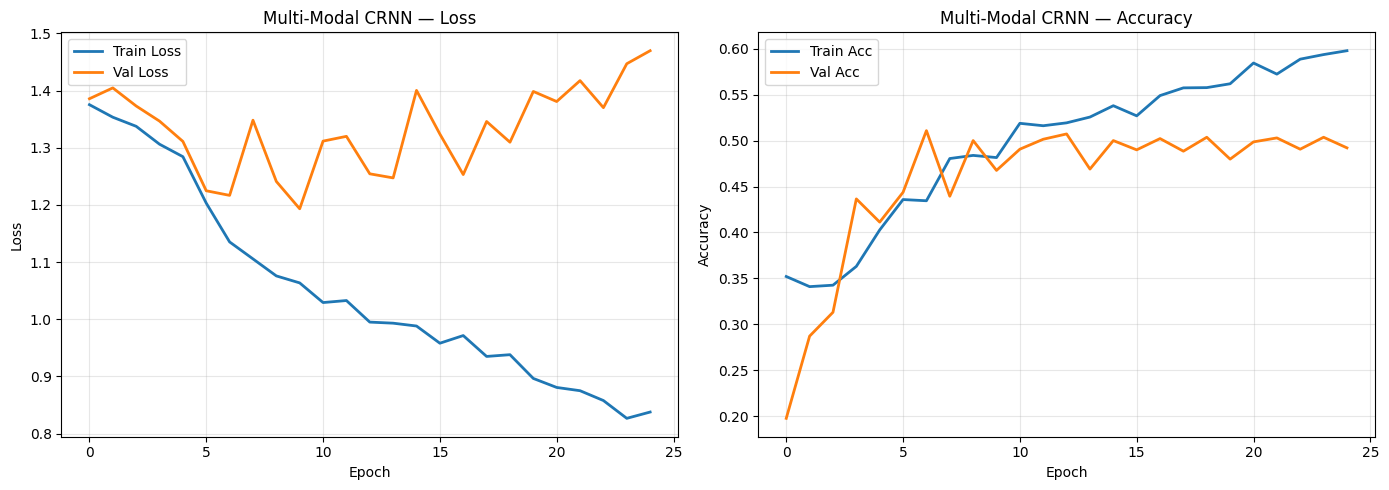


  Multi-Modal CRNN
  Accuracy:          0.3735
  F1 (macro):        0.3520
  F1 (weighted):     0.3175

              precision    recall  f1-score   support

      Normal       0.61      0.10      0.18       800
     Crackle       0.39      0.73      0.51       517
      Wheeze       0.28      0.38      0.32       224
        Both       0.31      0.57      0.40       162

    accuracy                           0.37      1703
   macro avg       0.40      0.44      0.35      1703
weighted avg       0.47      0.37      0.32      1703

  Saved: E:\GitHub\lung-sound-classification\outputs\figures\cm_multi-modal_crnn.png


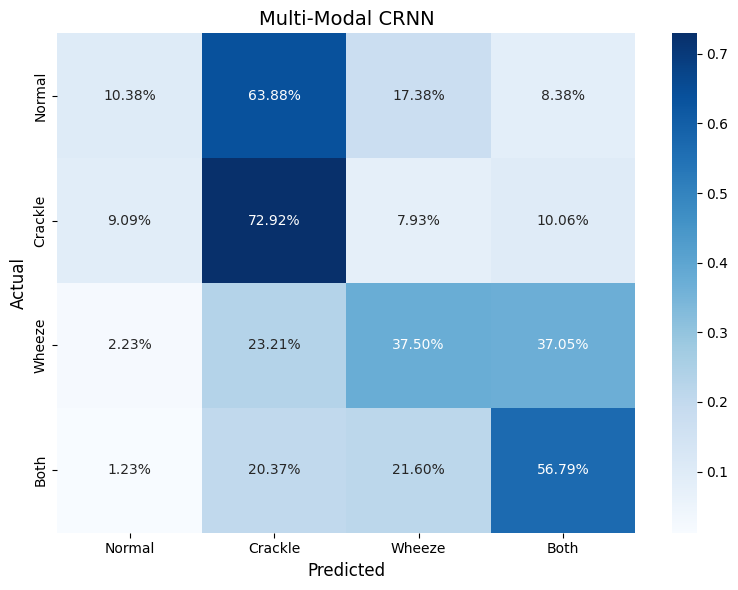

In [12]:
print("=" * 60)
print("  Training Multi-Modal CRNN (Audio + Demographics)")
print("=" * 60)

multi_history = train_model(
    model_multi, train_loader, val_loader,
    num_epochs=60, lr=3e-4, class_weights=weights_4class,
    model_name="multimodal_crnn", patience=15, multimodal=True
)

model_multi.load_state_dict(torch.load(MODELS_DIR / "multimodal_crnn_best.pt", map_location=device))
plot_training_curves(multi_history, title="Multi-Modal CRNN",
                     save_path=FIGURES_DIR / "multimodal_crnn_curves.png")
multi_results, y_true_multi, y_pred_multi = evaluate_model(
    model_multi, test_loader, "Multi-Modal CRNN", multimodal=True
)

## 5.8 Binary Classification (Normal vs Abnormal)
The clinically actionable question: does this respiratory cycle contain any abnormal sounds? This is a screening task — identifying patients who need further examination.

Binary model params: 2,585,827
  Training Binary Classifier (Normal vs Abnormal)
Epoch [  1/60] Train: 0.6867/0.5379  Val: 0.6560/0.6147  ★
Epoch [  3/60] Train: 0.6776/0.5482  Val: 0.6418/0.6212  ★
Epoch [  4/60] Train: 0.6713/0.5818  Val: 0.6387/0.6126  ★
Epoch [  5/60] Train: 0.6742/0.5797  Val: 0.6469/0.6248  
Epoch [ 10/60] Train: 0.6447/0.6395  Val: 0.6449/0.6147  
Epoch [ 15/60] Train: 0.6048/0.6913  Val: 0.6945/0.5498  

Early stopping at epoch 19
  Saved: E:\GitHub\lung-sound-classification\outputs\figures\binary_crnn_curves.png


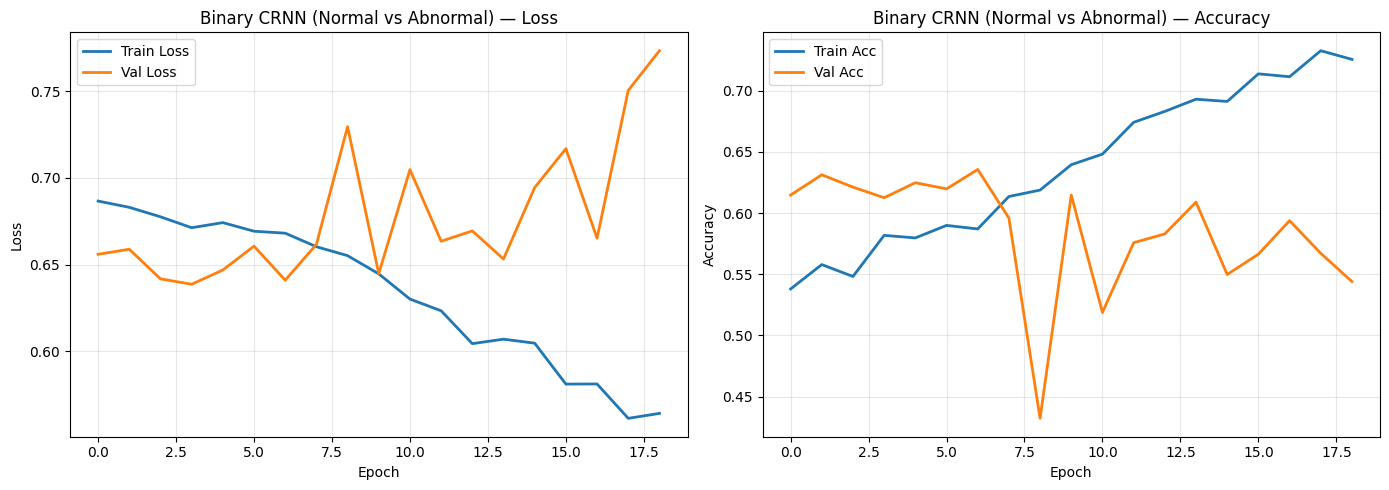


  Binary CRNN
  Accuracy:          0.5508
  F1 (macro):        0.4323
  F1 (weighted):     0.4480

              precision    recall  f1-score   support

      Normal       0.64      0.10      0.17       800
    Abnormal       0.54      0.95      0.69       903

    accuracy                           0.55      1703
   macro avg       0.59      0.53      0.43      1703
weighted avg       0.59      0.55      0.45      1703

  Saved: E:\GitHub\lung-sound-classification\outputs\figures\cm_binary.png


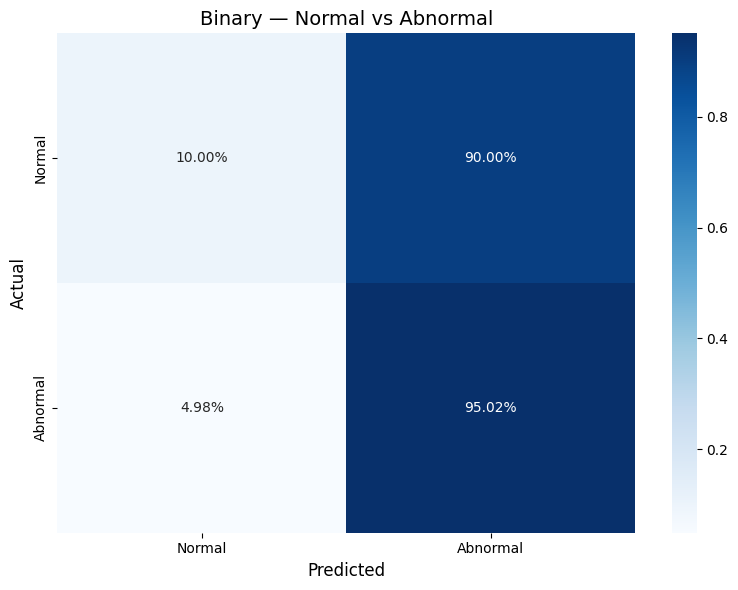

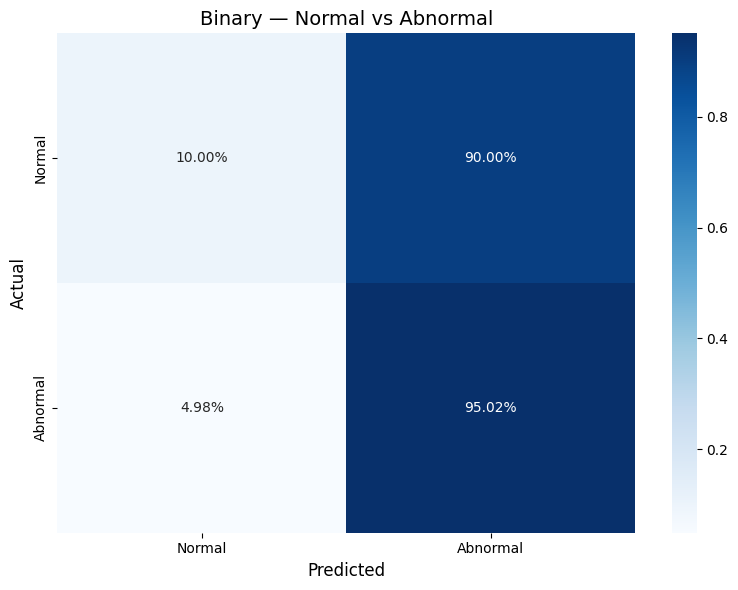

In [13]:
# Binary model (reuse AudioOnlyCRNN with 2 classes)
model_binary = AudioOnlyCRNN(num_classes=2).to(device)
print(f"Binary model params: {sum(p.numel() for p in model_binary.parameters()):,}")

# Need binary data loaders — reuse same dataset, just change label handling
def train_binary(model, train_loader, val_loader, num_epochs=60,
                 lr=3e-4, class_weights=None, model_name="model", patience=15):
    """Training loop for binary classification."""
    model = model.to(device)
    if class_weights is not None:
        class_weights = class_weights.to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimiser = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-3)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=num_epochs, eta_min=1e-6)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_loss = float('inf')
    patience_counter = 0

    for epoch in range(num_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for specs, labels_4, labels_bin in train_loader:
            specs, labels = specs.to(device), labels_bin.to(device)
            optimiser.zero_grad()
            outputs = model(specs)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimiser.step()
            running_loss += loss.item() * specs.size(0)
            _, pred = outputs.max(1)
            total += labels.size(0)
            correct += pred.eq(labels).sum().item()

        train_loss, train_acc = running_loss / total, correct / total

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for specs, labels_4, labels_bin in val_loader:
                specs, labels = specs.to(device), labels_bin.to(device)
                outputs = model(specs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * specs.size(0)
                _, pred = outputs.max(1)
                val_total += labels.size(0)
                val_correct += pred.eq(labels).sum().item()

        val_loss /= val_total
        val_acc = val_correct / val_total
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), MODELS_DIR / f"{model_name}_best.pt")
            patience_counter = 0
        else:
            patience_counter += 1

        if (epoch + 1) % 5 == 0 or patience_counter == 0:
            print(f"Epoch [{epoch+1:3d}/{num_epochs}] "
                  f"Train: {train_loss:.4f}/{train_acc:.4f}  "
                  f"Val: {val_loss:.4f}/{val_acc:.4f}  "
                  f"{'★' if patience_counter == 0 else ''}")

        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

    return history

# Need separate loaders without demographics for binary
train_ds_bin = MultiChannelDataset(train_df, augment=True, include_demographics=False)
val_ds_bin = MultiChannelDataset(val_df, augment=False, include_demographics=False)
test_ds_bin = MultiChannelDataset(test_df, augment=False, include_demographics=False)

train_loader_bin = DataLoader(train_ds_bin, batch_size=32, shuffle=True, num_workers=0)
val_loader_bin = DataLoader(val_ds_bin, batch_size=32, shuffle=False, num_workers=0)
test_loader_bin = DataLoader(test_ds_bin, batch_size=32, shuffle=False, num_workers=0)

print("=" * 60)
print("  Training Binary Classifier (Normal vs Abnormal)")
print("=" * 60)

binary_history = train_binary(
    model_binary, train_loader_bin, val_loader_bin,
    num_epochs=60, lr=3e-4, class_weights=weights_binary,
    model_name="binary_crnn", patience=15
)

# Evaluate binary
model_binary.load_state_dict(torch.load(MODELS_DIR / "binary_crnn_best.pt", map_location=device))
plot_training_curves(binary_history, title="Binary CRNN (Normal vs Abnormal)",
                     save_path=FIGURES_DIR / "binary_crnn_curves.png")

y_true_bin, y_pred_bin = [], []
model_binary.eval()
with torch.no_grad():
    for specs, labels_4, labels_bin in test_loader_bin:
        specs = specs.to(device)
        outputs = model_binary(specs)
        _, pred = outputs.max(1)
        y_true_bin.extend(labels_bin.numpy())
        y_pred_bin.extend(pred.cpu().numpy())

y_true_bin, y_pred_bin = np.array(y_true_bin), np.array(y_pred_bin)
binary_results = evaluate_predictions(
    y_true_bin, y_pred_bin,
    class_names=["Normal", "Abnormal"],
    title="Binary CRNN"
)
plot_confusion_matrix(
    y_true_bin, y_pred_bin,
    class_names=["Normal", "Abnormal"],
    title="Binary — Normal vs Abnormal",
    save_path=FIGURES_DIR / "cm_binary.png"
)

## 5.9 Final Comprehensive Comparison

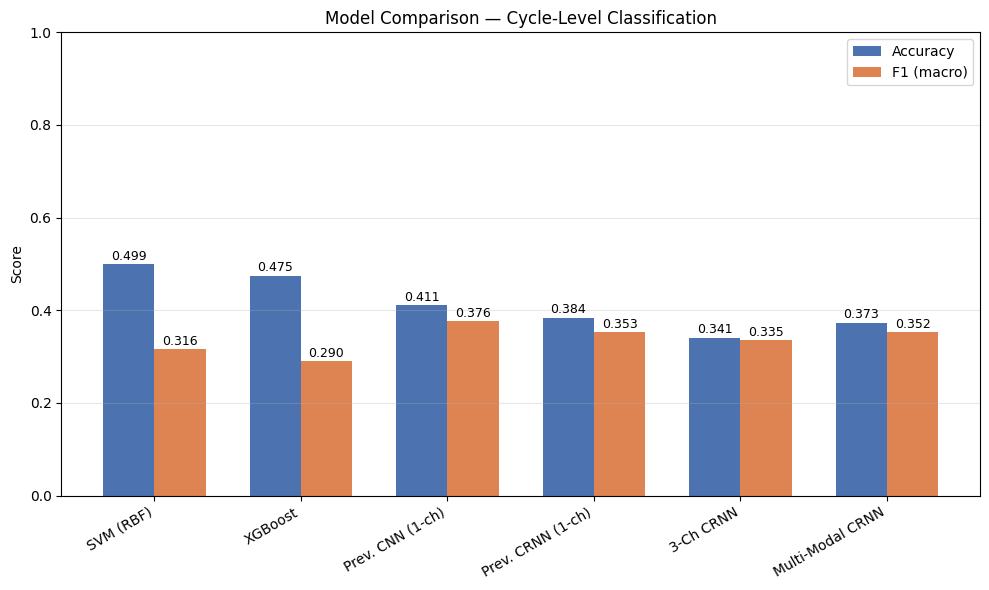


  COMPREHENSIVE RESULTS SUMMARY

Model                      Accuracy   F1 (macro)
------------------------------------------------
SVM (RBF)                    0.4990       0.3160
XGBoost                      0.4750       0.2900
Prev. CNN (1-ch)             0.4110       0.3760
Prev. CRNN (1-ch)            0.3840       0.3530
3-Ch CRNN                    0.3412       0.3349
Multi-Modal CRNN             0.3735       0.3520

Binary (Normal vs Abnormal)     0.5508       0.4323


In [14]:
all_results = {
    "SVM (RBF)": {"accuracy": 0.499, "f1_macro": 0.316},
    "XGBoost": {"accuracy": 0.475, "f1_macro": 0.290},
    "Prev. CNN (1-ch)": {"accuracy": 0.411, "f1_macro": 0.376},
    "Prev. CRNN (1-ch)": {"accuracy": 0.384, "f1_macro": 0.353},
    "3-Ch CRNN": audio_results,
    "Multi-Modal CRNN": multi_results,
}

compare_models(all_results, save_path=FIGURES_DIR / "comprehensive_comparison.png")

print("\n" + "=" * 60)
print("  COMPREHENSIVE RESULTS SUMMARY")
print("=" * 60)
print(f"\n{'Model':<24} {'Accuracy':>10} {'F1 (macro)':>12}")
print("-" * 48)
for name, res in all_results.items():
    print(f"{name:<24} {res['accuracy']:>10.4f} {res['f1_macro']:>12.4f}")

print(f"\n{'Binary (Normal vs Abnormal)':<24} {binary_results['accuracy']:>10.4f} {binary_results['f1_macro']:>12.4f}")